In [2]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']

dts = np.logspace(-2, 0, 11).tolist()
noise_levels = np.logspace(-3, 0, 10).tolist()

t_span = (0, 50)

# if a parameter is a list, the experiment will be run for each combination of the parameters
# if a parameter is not a list, the same value will be used for all experiments
# the first list will be the rows and the second list will be the columns
experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    'np_seed': 0,
    'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': noise_levels,
    't_eval_train': None, 'dt_train': dts, 't_span_train': t_span,
    'train_interpolation_dt': None,
    'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
}

results = run_experiment(experiment_config, use_ESINDy=True, use_ridge=True, generate_prediction=True)

rows are noise_level. there are 10 rows.
columns are dt_train. there are 11 columns.
step 1 of 10


100%|██████████| 11/11 [00:13<00:00,  1.26s/it]


step 2 of 10


100%|██████████| 11/11 [00:13<00:00,  1.21s/it]


step 3 of 10


...

100%|██████████| 11/11 [00:12<00:00,  1.18s/it]


step 9 of 10


100%|██████████| 11/11 [00:11<00:00,  1.07s/it]


step 10 of 10


100%|██████████| 11/11 [00:09<00:00,  1.17it/s]


rows are noise_level. there are 10 rows.
columns are dt_train. there are 11 columns.


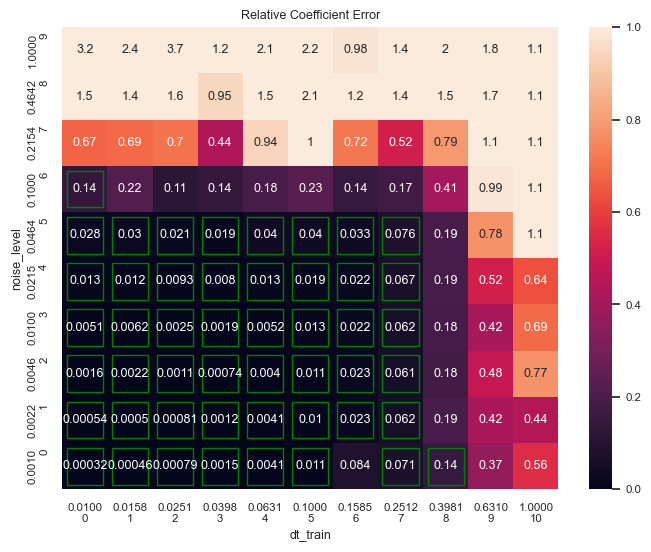

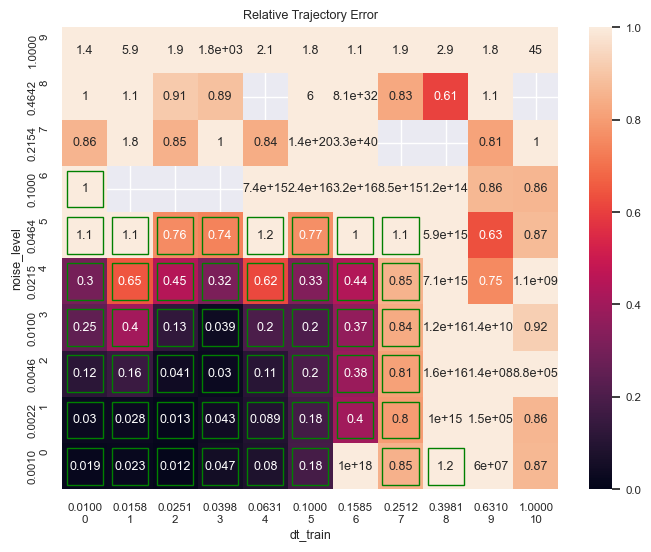

In [4]:
plot_heatmaps(experiment_config, results)

x0' = + 1.05597 x0 + -0.38211 x0 x1 
x1' = + -0.38532 x1 + 0.09601 x0 x1 


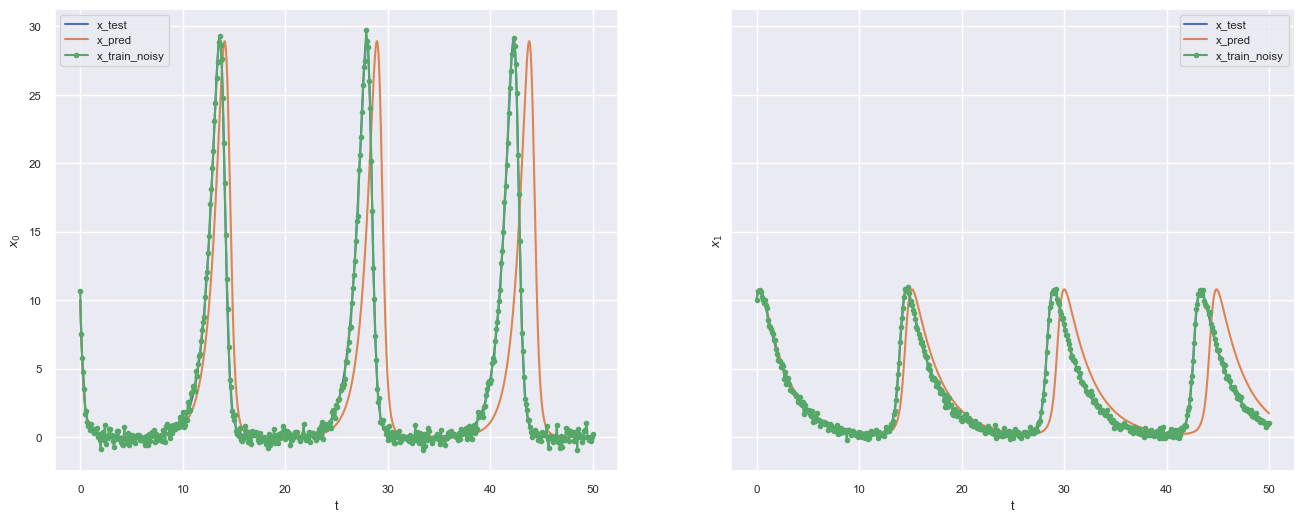

In [13]:
display_single_result(experiment_config, results, 5, 5, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])

x0' = + 1.09966 x0 + -0.39996 x0 x1 
x1' = + -0.39980 x1 + 0.10002 x0 x1 


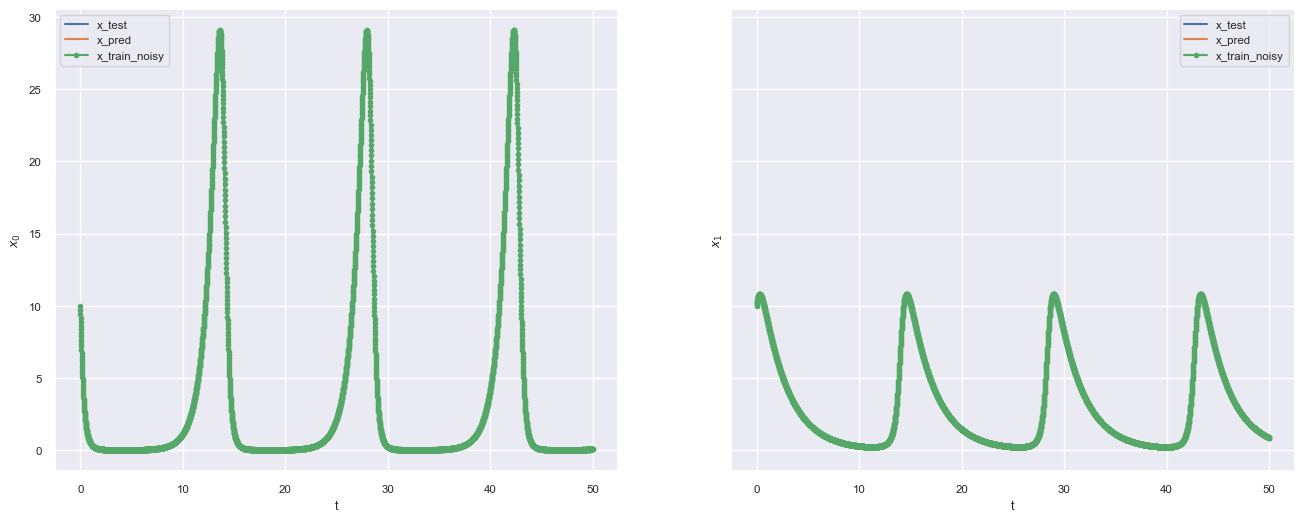

In [7]:
display_single_result(experiment_config, results, 0, 0, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])